Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°1**
## **Tema**: Hill Climbing ##

Integrantes:


*   Mamani, Pablo
*   Monteros, Milagros Maria
*   Rocha, Felipe





## Ejercicio 1
El siguiente código es una implementación simple del algoritmo Hill Climbing, al cual le faltan algunas líneas para funcionar correctamente. Su trabajo consiste en completar el código y probar el algoritmo con una función de prueba (Benchmark).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importar funciones declaradas en el archivo helper.
from helper_hill_climbing import validate_inputs, graficarCaminata, graficarEvolucionFitness
import random, math

La siguiente función calcula un nuevo punto de exploración a partir de un vector solución dado. La función es utilizada en el método de Hill Climbing.

In [ ]:
def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    Parameters
    ----------
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.

    Returns
    -------
    X : list
        Vector solución generado.
    R : list
        Vector dirección.p
    """
    R=[random.uniform(-max_eps,max_eps) for _ in range(len(X0))]

    X = [x + r for x, r in zip(X0, R)]

    return X, R

In [ ]:
import random
import math

def HillClimbing(fitness, X_mejor, max_eps, bounds, cant_iterac):
    """Algoritmo de Hill Climbing.

    Parameters:
    -----------
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.

    Return:
    -------
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """

    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []

    if not validate_inputs(X_mejor, bounds, cant_iterac, max_eps):
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

    # evaluacion inicial
    fX_mejor = fitness(X_mejor)

    # inicializar variables
    Trace_R.append([0 for xi in X_mejor])
    Trace_X.append(X_mejor)
    Trace_X_mejor.append(X_mejor)
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True

    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:
        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)

        # verifico y corrijo que X este dentro del dominio
        for i, xi in enumerate(X):
            X[i] = bounds[i][0] if xi < bounds[i][0] else xi
            X[i] = bounds[i][1] if xi > bounds[i][1] else xi

        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)

        # si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1

        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False

        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))

        # incremento el tiempo
        it = it + 1

        # imprimir solo si obtuve una mejor solucion
        if fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))

    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

Probar el algoritmo con el siguiente fragmento de código:

It.1: [1000] -> -1000000
It.2: [1000] -> -1000000
It.3: [926.58] -> -858545.0798
It.4: [865.51] -> -749113.2962
It.6: [843.97] -> -712281.8317
It.8: [747.74] -> -559117.6452
It.9: [666.78] -> -444594.1835
It.10: [651.74] -> -424761.0136
It.11: [579.63] -> -335972.0065
It.12: [543.82] -> -295735.2046
It.13: [521.38] -> -271837.9424
It.14: [462.48] -> -213884.2814
It.15: [381.18] -> -145296.3433
It.17: [323.07] -> -104376.3735
It.20: [301.71] -> -91030.138
It.21: [270.54] -> -73190.9138
It.22: [210.38] -> -44257.8163
It.23: [123.76] -> -15315.5619
It.24: [85.43] -> -7298.6205
It.25: [17.78] -> -316.0103
It.30: [7.11] -> -50.6222
It.45: [6.91] -> -47.708
It.49: [-3.12] -> -9.7639
It.69: [1.73] -> -3.004
-----
Solución: [1.7331979168393445]
Fitness: -3.0039750189362433
Iteraciones: 110


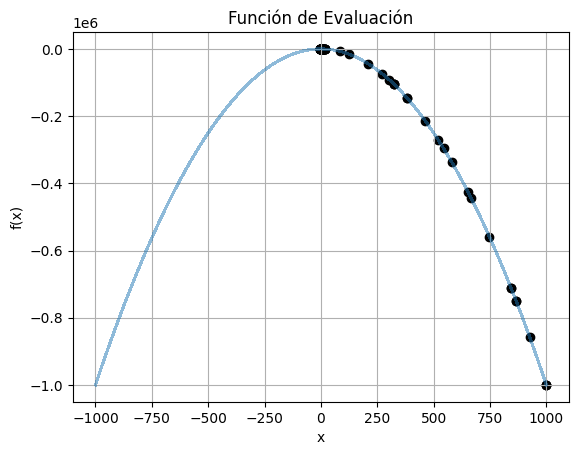

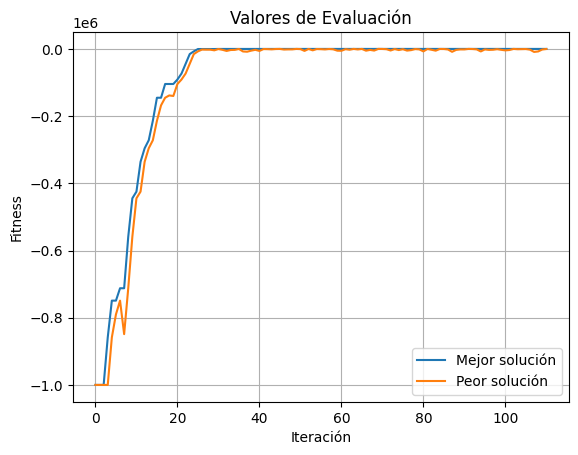

In [ ]:
def parabola(x_vars):
    return -sum([x**2 for x in x_vars])

n_variables = 1
bounds = [(-1000,1000) for i in range(n_variables)]
x0 = [row[1] for row in bounds] # punto inicial en una de las esquinas

rango = bounds[0][1] - bounds[0][0]

max_eps = 0.05 * rango
cant_iterac = int(rango / max_eps * 2)

resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    parabola, x0, max_eps, bounds, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(parabola, Trace_X_mejor, bounds, resolution_grafico)
graficarEvolucionFitness(Trace_f)

**Cambio de código para cubrir cualquier rango establecido**

Para cumplir con la consigna de robustez del problema, decidimos realizar el cambio en la función de parábola y calcular automáticamente los parámetros principales del algoritmo que son el tamaño de paso y cantidad de iteraciones.

Primero, identificamos el rango real de búsqueda a través de la resta de los límites, con la línea rango = bounds - bounds. Con este valor, definimos el tamaño máximo de paso max_eps como un 5% del rango total, asegurando que el algoritmo realice una exploración eficiente para cualquier tamaño de dominio. Luego, para garantizar que el algoritmo tenga margen suficiente para recorrer el rango más de una vez y evitar que quede estancado en zonas acotadas, calculamos la cantidad total de iteraciones con la expresión cant_iterac = int(rango / max_eps * 2).

Podemos concluir que logramos que el algoritmo de Hill Climbing no presente este tipo de error cuando utilizamos un mayor rango, cumpliendo con la teoría del propio algoritmo: moverse localmente y avanzar paso a paso hacia el óptimo.

## Ejercicio 2
Contestar las siguientes preguntas:
1.    ¿El algoritmo proporcionado está diseñado para buscar el máximo o el mínimo de la función?

2.    Explicar con sus palabras en qué consiste la condición de terminación propuesta.



**Respuesta 1:** El algoritmo proporcionado esta diseñado para buscar el máximo local dentro del rango establecido en la función y que esta solución sea próxima a la variable inicial que uno elige al azar.

**Respuesta 2:** En el algoritmo presentado, primero definimos una variable "cant_iterac", en la cual calibramos una cierta cantidad de iteracciones para que el algoritmo se detenga cuando se acumulen intentos fallidos de la condicion "si la solucion actual es mejor que la que ya tenía". Esto hace que el corte ocurra cuando la búsqueda se estanque cerca de un óptimo o en una meseta. Por eso, la condicion de determinacion no depende de un número total de iteraciones, sino de una racha de intentos consecutivos sin encontrar una mejora en la solución.

## Ejercicio 3

Reutilizando el código anterior, compruebe el funcionamiento del algoritmo buscando un óptimo local en los siguientes casos:
1.   F(x, y) = -x^2 - y^2, x, y ∈ [-5, 5]
2.   g(x)= -0.01 x^2 - cos(2x), x ∈ [-4𝜋, 4𝜋]
3.   G(x, y) = -0.01(x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

En cada caso se pide:
1.   Ajuste adecuadamente los parámetros del algoritmo (tamaño máximo del paso y cantidad de iteraciones), de manera de asegurar que encuentre un óptimo local independientemente de cuál sea el punto inicial, en más del 80% de las ejecuciones. Considere dos cifras decimales de precisión para determinar que llegó al óptimo.
2.    Genere un gráfico con la “caminata” realizada, es decir donde se muestre todos los puntos por donde el algoritmo fue explorando, desde el punto inicial hasta llegar a la solución final.
3.    Generar un gráfico con los valores de fitness de las soluciones encontradas en cada iteración del algoritmo.

It.1: [90.13, 97.16] -> -17562.9373
It.3: [82.24, 100] -> -16763.023
It.4: [80.3, 96.95] -> -15847.6122
It.5: [76.09, 95.32] -> -14875.4604
It.7: [67.31, 99.77] -> -14485.4632
It.8: [63.71, 91.47] -> -12426.2605
It.9: [70.59, 83.65] -> -11979.9147
It.11: [68.78, 77.72] -> -10771.9296
It.12: [64.83, 75.01] -> -9830.3169
It.13: [67.74, 66.39] -> -8996.4619
It.16: [58.08, 73.03] -> -8706.9106
It.19: [63.35, 68.14] -> -8657.0164
It.21: [53.91, 75.16] -> -8554.9057
It.25: [52.82, 68.02] -> -7417.0278
It.26: [43.87, 68.8] -> -6657.6722
It.27: [35.92, 67.85] -> -5893.4183
It.28: [30.15, 69.39] -> -5723.5162
It.29: [25.89, 67.87] -> -5277.3295
It.31: [27.52, 63.82] -> -4830.2963
It.33: [18.53, 61.94] -> -4180.1448
It.35: [8.78, 55.82] -> -3192.5978
It.37: [13.33, 52.05] -> -2886.5994
It.38: [18.21, 50.43] -> -2874.8065
It.39: [10.01, 50.85] -> -2685.5733
It.43: [3.62, 42.27] -> -1799.9017
It.44: [4.4, 40.38] -> -1649.835
It.45: [12.06, 31.63] -> -1145.6086
It.46: [11.45, 25.64] -> -788.4478
It

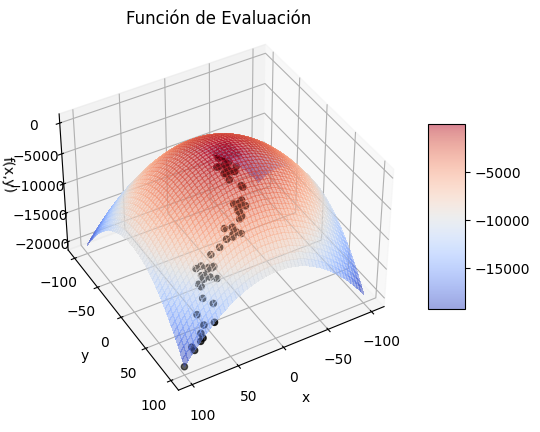

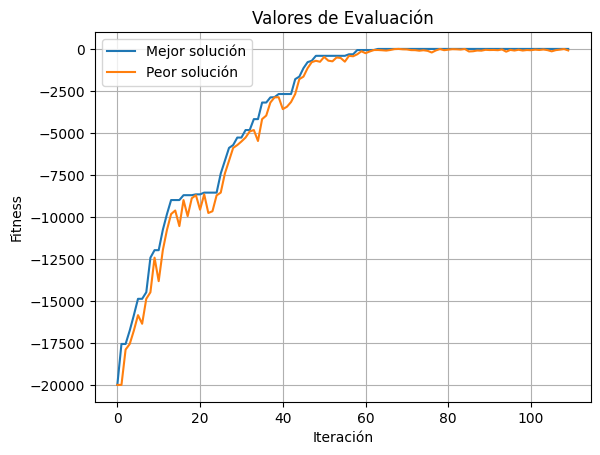

In [ ]:
import math as plt
def f(X_vars):
    return -sum([xi**2 for xi in X_vars])

bounds_F = [(-100,100), (-100,100)]
x0=[row[1] for row in bounds_F]
n_variables = len(bounds_F)
#... COMPLETAR ...#

rangos = [b[1] - b[0] for b in bounds_F]
rango_promedio = sum(rangos) / n_variables

max_eps = 0.05 * rango_promedio
cant_iterac = int(rango_promedio / max_eps * 2)

resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    f, x0, max_eps, bounds_F, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(f, Trace_X, bounds_F, resolution_grafico)
graficarEvolucionFitness(Trace_f)


**Cambio en el código por modificación del ejercicio 1**

Como la función propuesta para este punto es la siguiente:
*   F(x, y) = -x^2 - y^2, x, y ∈ [-5, 5]

Al tener rangos que se pueden modificar, decidimos realizar la misma calibración automática del paso y cantidad de iteraciones para asegurarmos que la heurística funcione correctamente cuando se cambie el rango.

Para el resto de las funciones, decidimos no aplicar este cambio porque ya tienen rangos establecidos y limitados por ser funciones periódicas.

It.1: [12.1] -> -146.2962
It.2: [10.97] -> -120.3451
It.5: [10.83] -> -117.2612
It.6: [10.78] -> -116.2771
It.7: [10.1] -> -102.0019
It.8: [9.06] -> -82.1581
It.10: [8.39] -> -70.4076
It.14: [7.96] -> -63.4322
It.17: [6.99] -> -48.8808
It.25: [6.45] -> -41.5826
It.26: [5.68] -> -32.2761
It.27: [4.76] -> -22.6728
It.28: [4.35] -> -18.9022
It.29: [3.21] -> -10.2811
It.36: [2.79] -> -7.7938
It.37: [2.63] -> -6.904
It.39: [2.31] -> -5.3484
It.40: [1.16] -> -1.335
It.41: [0.99] -> -0.9821
It.42: [0.62] -> -0.3842
It.43: [0.22] -> -0.0493
It.44: [0.14] -> -0.0189
It.52: [0.12] -> -0.0143
It.54: [0.1] -> -0.0095
It.65: [-0.09] -> -0.0086
It.68: [0.0] -> -0.0
-----
Solución: [0.0035355166856541054]
Fitness: -1.249987823453859e-05
Iteraciones: 109


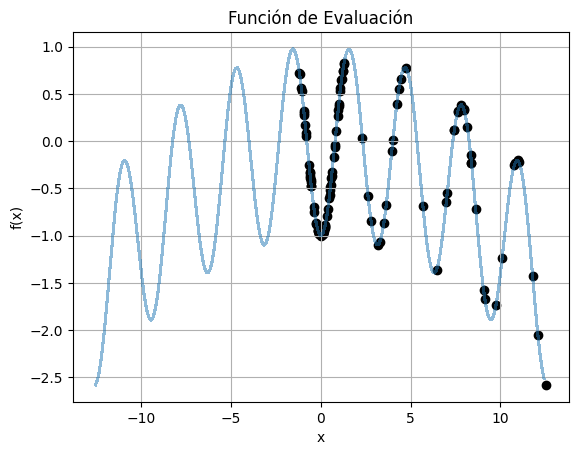

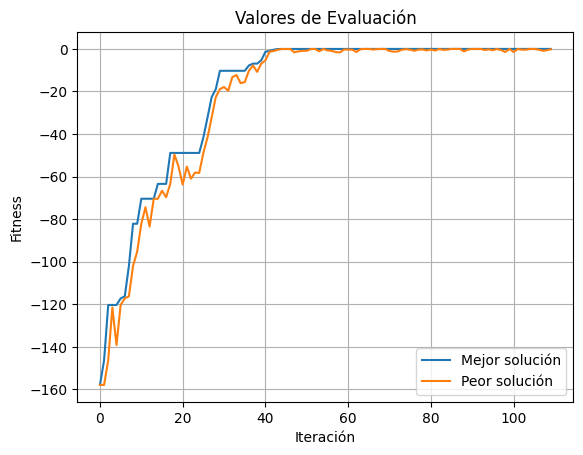

In [ ]:
import math
def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_g = [(-4*math.pi, 4*math.pi)]
n_variables = len(bounds_g)
x0 = [row[1] for row in bounds_g]

#... COMPLETAR ...#

rango = bounds_g[0][1] - bounds_g[0][0]
max_eps = 0.05 * rango
cant_iterac = int(rango / max_eps * 2)

resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    f, x0, max_eps, bounds_g, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(g, Trace_X, bounds_g, 0.1)
graficarEvolucionFitness(Trace_f)


It.1: [12.35, 12.57] -> -5.0091
It.3: [12.35, 12.44] -> -4.9556
It.4: [12.16, 12.42] -> -4.6576
It.5: [12.12, 12.48] -> -4.6446
It.7: [11.83, 12.57] -> -4.0765
It.8: [11.65, 12.57] -> -3.6809
It.9: [11.45, 12.52] -> -3.2588
It.10: [11.27, 12.28] -> -2.7699
It.12: [10.97, 12.38] -> -2.6714
It.14: [10.95, 12.21] -> -2.4483
It.15: [10.99, 12.03] -> -2.1359
It.18: [10.83, 11.77] -> -1.6
It.24: [11.12, 11.53] -> -1.1148
It.25: [10.86, 11.25] -> -0.6025
It.28: [10.85, 11.03] -> -0.4369
It.32: [10.87, 10.9] -> -0.4195
It.33: [10.91, 10.96] -> -0.4086
It.50: [10.97, 10.96] -> -0.408
It.95: [10.94, 10.96] -> -0.4068


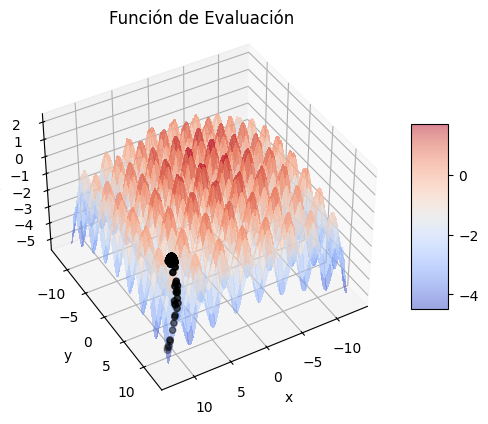

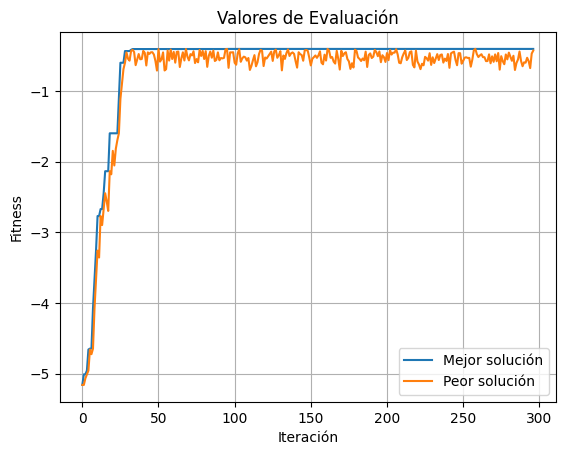

In [ ]:
import math
def G(X_vars):
    x, y = X_vars
    return -0.01 * (x**2 + y**2) - math.cos(2*x) - math.cos(2*y)
bounds_G = [(-4*math.pi, 4*math.pi) for i in range (2)]
x0=[row[1] for row in bounds_G]

#... COMPLETAR ...#
max_eps = 0.3
cant_iterac = 200
resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    G, x0, max_eps, bounds_G, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(G, Trace_X, bounds_G, 0.1)
graficarEvolucionFitness(Trace_f)

**Actividad Complementaria:** Como actividad complementaria se solicita realizar las gráfica de puntos aleatorios. Usar de base el código de puntoExploración, aplicar las modificaciones necesarias para generar las gráficas en R2 (ya que es más facil de ver el comportamiento) de:


1.   Random
2.   E = random * E_max
3.   Vector R
4.   R / norm(R)



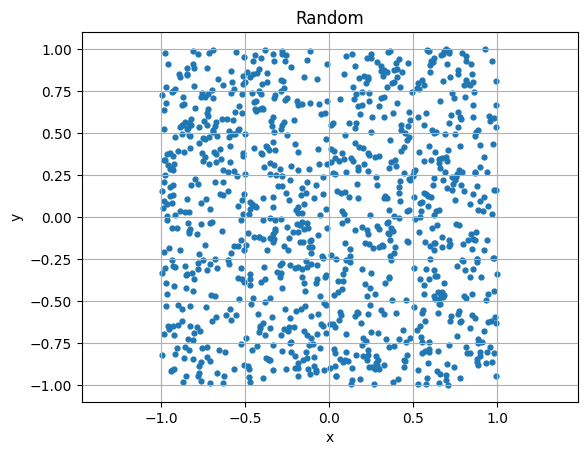

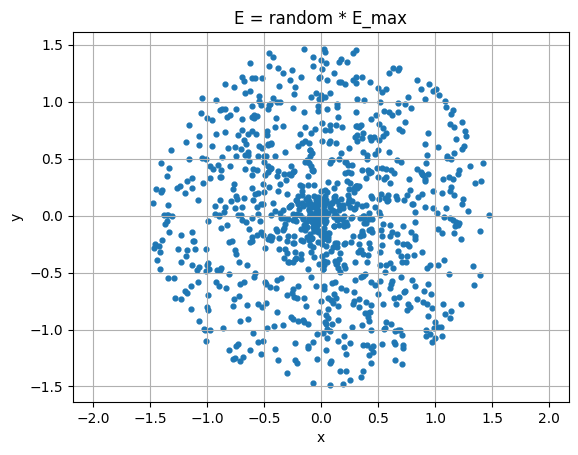

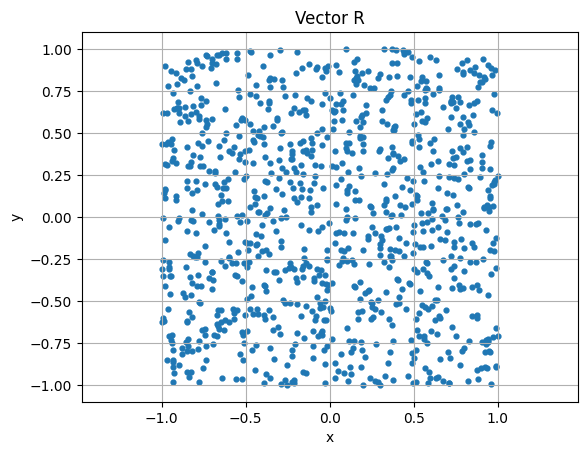

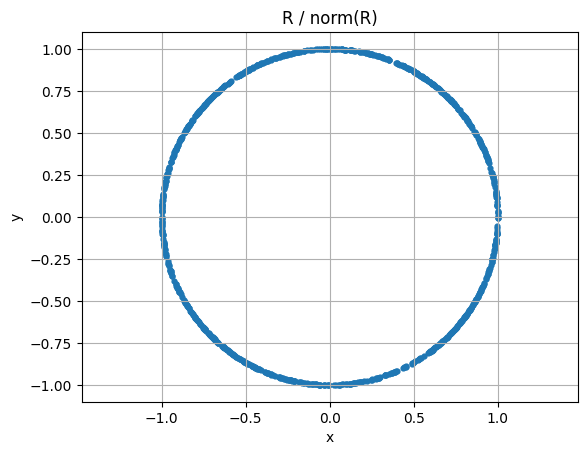

In [ ]:
import matplotlib.pyplot as plt
import math, random

def puntosRandomCuadrado(N):
  return [(random.uniform(-1,1),random.uniform(-1,1)) for _ in range(N)]

def puntosRandomRadio(N, E_max):
  puntos = []
  for _ in range(N):
    E = random.uniform(0, E_max)
    theta = random.uniform(0, 2*math.pi)
    puntos.append((E*math.cos(theta), E*math.sin(theta)))
  return puntos

def vectoresRandom(N):
  return [(random.uniform(-1,1),random.uniform(-1,1)) for _ in range(N)]

def direccionesUnit(N):
  puntos = []
  for _ in range(N):
     rx, ry = random.uniform(-1,1), random.uniform(-1,1)
     norm = math.hypot(rx, ry)
     if norm == 0.0:
            rx, ry, norm = 1.0, 0.0, 1.0
     puntos.append((rx/norm, ry/norm))
  return puntos

def scatterPoints(puntos, titulo):
  xs, ys = zip(*puntos)
  plt.figure()
  plt.scatter(xs, ys, s=12)
  plt.title(titulo)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.axis("equal")
  plt.grid(True)

N=1000
E_max = 1.5

scatterPoints(puntosRandomCuadrado(N), "Random")
scatterPoints(puntosRandomRadio(N, E_max), "E = random * E_max")
scatterPoints(vectoresRandom(N), "Vector R")
scatterPoints(direccionesUnit(N), "R / norm(R)")
#

**Conclusión**

Estos gráficos nos permiten verificar visualmente que el producto ϵ⋅R en el algoritmo Hill Climbing genera saltos bien distribuidos y variados en dirección y magnitud. De esta manera, podemos ver el correcto funcionamiento del método y asegurarnos que no haya manipulación indebida en la generación de pasos durante la heurística.